Disciplina: Soluções em Energias Renováveis e Sustentáveis <br>
Turma: 1CCPQ <br>
Alunos:<br>
Artur Souza Pereira - RM 570880<br>
Gustavo Gamba Zancopé - RM 569287<br>
Isabela Camargo Souza - RM 569196<br>
Miguel Silvério de Avila - RM 568873<br>
Victor Vieira Galvão - RM 571483<br>

# Avaliação — APIs, energias renováveis e aprendizado de máquina

**Objetivo:** consultar duas APIs públicas (ANEEL/SIGA e Open-Meteo), gerar os CSVs e resolver duas tarefas independentes, comparando **três algoritmos em cada uma**:

| Tarefa | Problema | Fonte | Algoritmos comparados |
|---|---|---|---|
| 1 | Classificação da fonte (Solar, Eólica, Hidráulica) | ANEEL — SIGA | Regressão Logística, kNN, Random Forest |
| 2 | Regressão da radiação solar em Petrolina (PE) | Open-Meteo (histórico) | Regressão Linear, Árvore de Decisão, Random Forest |

**Como executar:** no Colab, use *Ambiente de execução → Executar tudo*. As APIs públicas não exigem token. Se uma consulta falhar, o notebook usa automaticamente os CSVs de contingência (veja a seção 1).

## 0. Imports e configurações gerais

In [ ]:
import json, csv, os, urllib.parse, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Classificação
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

# Regressão
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42                      # semente fixa para reprodutibilidade
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## 1. Consulta às APIs e geração dos CSVs

As duas consultas são públicas e **não exigem token**. A função abaixo monta a URL, faz o `GET` e converte o JSON.

In [ ]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

URL_FALLBACK = "https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/"

### 1.1 ANEEL (SIGA) → `aneel_classificacao_orange.csv`

In [ ]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
FONTES = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica", "PCH": "Hidráulica", "CGH": "Hidráulica"}

def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

try:
    registros_aneel = []
    for sigla in SIGLAS:
        resp = consultar_api(URL_ANEEL, {"resource_id": ID_RECURSO,
                                         "filters": json.dumps({"SigTipoGeracao": sigla}),
                                         "limit": 1200})
        if not resp.get("success"):
            raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
        linhas = resp["result"]["records"]
        print(f"{sigla}: {len(linhas)} linhas recebidas")
        registros_aneel.extend(linhas)

    linhas_classificacao = []
    for r in registros_aneel:
        pot, lat, lon = (numero(r.get("MdaPotenciaOutorgadaKw")),
                         numero(r.get("NumCoordNEmpreendimento")),
                         numero(r.get("NumCoordEEmpreendimento")))
        fonte = FONTES.get(r.get("SigTipoGeracao"))
        if fonte and None not in (pot, lat, lon):
            linhas_classificacao.append([pot, lat, lon, fonte])
    if len(linhas_classificacao) < 90:
        raise ValueError("Poucos registros válidos")

    with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as f:
        w = csv.writer(f); w.writerow(["potencia_kw", "latitude", "longitude", "fonte"]); w.writerows(linhas_classificacao)
    ORIGEM_ANEEL = "API ANEEL (consulta ao vivo)"
except Exception as e:
    print("⚠️ API da ANEEL indisponível:", e, "\n   Usando CSV de contingência.")
    if not os.path.exists("aneel_classificacao_orange.csv"):
        urllib.request.urlretrieve(URL_FALLBACK + "aneel_classificacao_orange.csv", "aneel_classificacao_orange.csv")
    ORIGEM_ANEEL = "CSV de contingência"
print("Origem dos dados da Tarefa 1:", ORIGEM_ANEEL)

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Origem dos dados da Tarefa 1: API ANEEL (consulta ao vivo)


### 1.2 Open-Meteo (Petrolina–PE, 01/04/2025 a 30/06/2025) → `meteo_regressao_orange.csv`

In [ ]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
NOMES_API = ["temperature_2m", "relative_humidity_2m", "cloud_cover", "wind_speed_10m", "shortwave_radiation"]
params_meteo = {"latitude": -9.39, "longitude": -40.50,
                "start_date": "2025-04-01", "end_date": "2025-06-30",
                "timezone": "America/Recife", "hourly": ",".join(NOMES_API)}
try:
    resp = consultar_api(URL_METEO, params_meteo)
    if "hourly" not in resp:
        raise ValueError("Resposta sem a seção hourly")
    h = resp["hourly"]
    print("Unidades informadas pela API:", resp.get("hourly_units", {}))
    linhas_regressao = []
    for i, data_hora in enumerate(h["time"]):
        hora = int(data_hora[11:13])
        vals = [h[n][i] for n in NOMES_API]
        if 7 <= hora <= 17 and None not in vals:
            linhas_regressao.append([data_hora, *vals[:4], hora, vals[4]])
    if len(linhas_regressao) < 100:
        raise ValueError("Poucos horários válidos")
    with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as f:
        w = csv.writer(f)
        w.writerow(["data_hora", "temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
        w.writerows(linhas_regressao)
    ORIGEM_METEO = "API Open-Meteo (consulta ao vivo)"
except Exception as e:
    print("⚠️ API Open-Meteo indisponível:", e, "\n   Usando CSV de contingência.")
    if not os.path.exists("meteo_regressao_orange.csv"):
        urllib.request.urlretrieve(URL_FALLBACK + "meteo_regressao_orange.csv", "meteo_regressao_orange.csv")
    ORIGEM_METEO = "CSV de contingência"
print("Origem dos dados da Tarefa 2:", ORIGEM_METEO)

Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Origem dos dados da Tarefa 2: API Open-Meteo (consulta ao vivo)


---
# Tarefa 1 — Classificação da fonte renovável (ANEEL)

**Pergunta:** a partir da **potência outorgada** e da **localização**, é possível classificar a fonte de um empreendimento como Solar, Eólica ou Hidráulica?

- **X:** `potencia_kw`, `latitude`, `longitude`
- **y:** `fonte` (Solar = UFV; Eólica = EOL; Hidráulica = UHE + PCH + CGH)
- Não são usados nome, código CEG, sigla ou descrição, pois entregariam a resposta.
- A potência é **outorgada** (capacidade autorizada), não energia gerada.

### 2. Carga e exploração dos dados

In [ ]:
df_cls = pd.read_csv("aneel_classificacao_orange.csv", encoding="utf-8-sig")
print("Formato:", df_cls.shape)
display(df_cls.head())
print("\nTipos das colunas:"); print(df_cls.dtypes)
print("\nValores ausentes por coluna:"); print(df_cls.isna().sum())
print("\nDuplicatas exatas:", df_cls.duplicated().sum())

Formato: (3876, 4)


,potencia_kw,latitude,longitude,fonte
0,20.4800,-10.4428,-64.1519,Solar
1,"5,000.0000",-6.0039,-40.2747,Solar
2,12.2600,-23.5578,-46.7340,Solar
3,3.0000,-23.5589,-46.7350,Solar
4,1.7000,-23.4938,-46.8450,Solar



Tipos das colunas:
potencia_kw    float64
latitude       float64
longitude      float64
fonte           object
dtype: object

Valores ausentes por coluna:
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

Duplicatas exatas: 27


In [ ]:
cont = df_cls["fonte"].value_counts()
prop = df_cls["fonte"].value_counts(normalize=True).mul(100).round(1)
display(pd.DataFrame({"empreendimentos": cont, "%": prop}))
display(df_cls.groupby("fonte")[["potencia_kw", "latitude", "longitude"]].describe().T)

,empreendimentos,%
fonte,,
Hidráulica,1476,38.1000
Solar,1200,31.0000
Eólica,1200,31.0000


fonte                   Eólica      Hidráulica        Solar
potencia_kw count   1,200.0000      1,476.0000   1,200.0000
            mean   30,748.3532     75,809.1583  10,812.7367
            std    13,785.2990    486,419.5790  17,664.6569
            min         0.1600          0.9900       0.2600
            25%    23,100.0000        990.0000       1.0000
            50%    29,600.0000      4,000.0000       1.0000
            75%    37,200.0000     17,000.0000  27,000.0000
            max   105,000.0000 11,233,100.0000 137,480.0000
latitude    count   1,200.0000      1,476.0000   1,200.0000
            mean       -9.8665        -21.1570      -5.0742
            std         7.5217          6.4349       5.5650
            min       -33.7228        -30.7880     -29.8355
            25%       -11.1315        -26.7570      -6.9246
            50%        -7.9781        -22.0332      -2.0435
            75%        -5.2714        -17.6452      -1.7961
            max         0.0000          3.8017       3.8314
longitude   count   1,200.0000      1,476.0000   1,200.0000
            mean      -39.7010        -49.0307     -49.4474
            std         7.2322          7.6678       5.7107
            min       -55.9308        -64.6461     -69.9414
            25%       -41.8128        -52.6474     -53.0678
            50%       -40.6860        -50.4259     -52.4644
            75%       -36.4889        -46.2166     -45.0718
            max         0.0000          0.0000     -35.2354

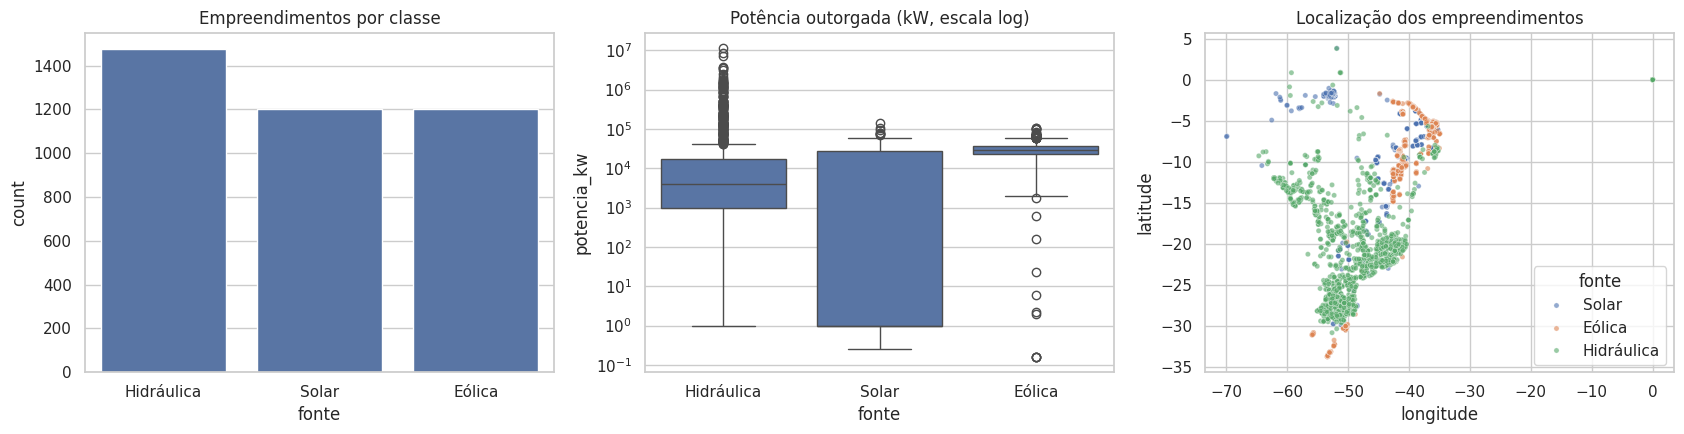

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
sns.countplot(data=df_cls, x="fonte", order=cont.index, ax=ax[0]); ax[0].set_title("Empreendimentos por classe")
sns.boxplot(data=df_cls, x="fonte", y="potencia_kw", order=cont.index, ax=ax[1])
ax[1].set_yscale("log"); ax[1].set_title("Potência outorgada (kW, escala log)")
sns.scatterplot(data=df_cls, x="longitude", y="latitude", hue="fonte", s=14, alpha=.6, ax=ax[2])
ax[2].set_title("Localização dos empreendimentos")
plt.tight_layout(); plt.show()

**Observações da exploração.** Não há valores ausentes (as linhas incompletas já foram descartadas na geração do CSV). As classes têm tamanhos próximos, mas a Hidráulica é a maior porque agrega três siglas. A potência varia em várias ordens de grandeza (por isso a escala log e a padronização), e as fontes têm distribuição geográfica diferente (veja o mapa de dispersão). Atenção: o limite de 1.200 registros por sigla na consulta faz com que as proporções **não representem a matriz elétrica brasileira**.

### 3. Definição de X, y e divisão estratificada 80/20

In [ ]:
FEATURES_CLS = ["potencia_kw", "latitude", "longitude"]
X = df_cls[FEATURES_CLS]
y = df_cls["fonte"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
print(f"Treino: {X_tr.shape[0]} | Teste: {X_te.shape[0]}")
display(pd.DataFrame({"treino (%)": y_tr.value_counts(normalize=True)*100,
                      "teste (%)": y_te.value_counts(normalize=True)*100}).round(1))

Treino: 3100 | Teste: 776


,treino (%),teste (%)
fonte,,
Hidráulica,38.1000,38.1000
Solar,31.0000,30.9000
Eólica,31.0000,30.9000


### 4. Modelos
Todos usam **exatamente a mesma divisão** treino/teste. Regressão Logística e kNN dependem de escala/distância, então usam `StandardScaler` dentro de um `Pipeline` (o escalonador é ajustado **somente no treino**). Random Forest não exige padronização.

| Modelo | Por que foi escolhido |
|---|---|
| Regressão Logística | Linha de base linear e interpretável |
| kNN (k=5) | Baseado em vizinhança: útil quando a localização separa as classes |
| Random Forest (200 árvores) | Captura relações não lineares e interações entre potência e localização |

In [ ]:
modelos_cls = {
    "Regressão Logística": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=SEED)),
    "kNN (k=5)":           make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
}
CLASSES = sorted(y.unique())
linhas, previsoes_cls = [], {}
for nome, m in modelos_cls.items():
    m.fit(X_tr, y_tr)
    p = m.predict(X_te); previsoes_cls[nome] = p
    linhas.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_te, p),
        "Precision (macro)": precision_score(y_te, p, average="macro", zero_division=0),
        "Recall (macro)":    recall_score(y_te, p, average="macro", zero_division=0),
        "F1 (macro)":        f1_score(y_te, p, average="macro", zero_division=0),
        "F1 (weighted)":     f1_score(y_te, p, average="weighted", zero_division=0),
    })
tab_cls = pd.DataFrame(linhas).set_index("Modelo")
print("Métricas no conjunto de teste (mesma divisão estratificada 80/20, seed=42).")
print("Precision, Recall e F1 usam média MACRO (todas as classes pesam igual); F1 weighted é informado como complemento.")
display(tab_cls.style.highlight_max(axis=0, color="#c8e6c9").format("{:.4f}"))

Métricas no conjunto de teste (mesma divisão estratificada 80/20, seed=42).
Precision, Recall e F1 usam média MACRO (todas as classes pesam igual); F1 weighted é informado como complemento.


,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
Modelo,,,,,
Regressão Logística,0.8235,0.8275,0.8200,0.8182,0.8222
kNN (k=5),0.9665,0.9677,0.9649,0.9662,0.9664
Random Forest,0.9768,0.9779,0.9755,0.9765,0.9768


### 5. Métricas por classe e matrizes de confusão

In [ ]:
for nome, p in previsoes_cls.items():
    print(f"===== {nome} =====")
    print(classification_report(y_te, p, labels=CLASSES, zero_division=0, digits=3))

===== Regressão Logística =====
              precision    recall  f1-score   support

      Eólica      0.742     0.900     0.814       240
  Hidráulica      0.880     0.868     0.874       296
       Solar      0.860     0.692     0.767       240

    accuracy                          0.823       776
   macro avg      0.828     0.820     0.818       776
weighted avg      0.831     0.823     0.822       776

===== kNN (k=5) =====
              precision    recall  f1-score   support

      Eólica      0.975     0.963     0.969       240
  Hidráulica      0.954     0.986     0.970       296
       Solar      0.974     0.946     0.960       240

    accuracy                          0.966       776
   macro avg      0.968     0.965     0.966       776
weighted avg      0.967     0.966     0.966       776

===== Random Forest =====
              precision    recall  f1-score   support

      Eólica      0.971     0.979     0.975       240
  Hidráulica      0.967     0.993     0.980      

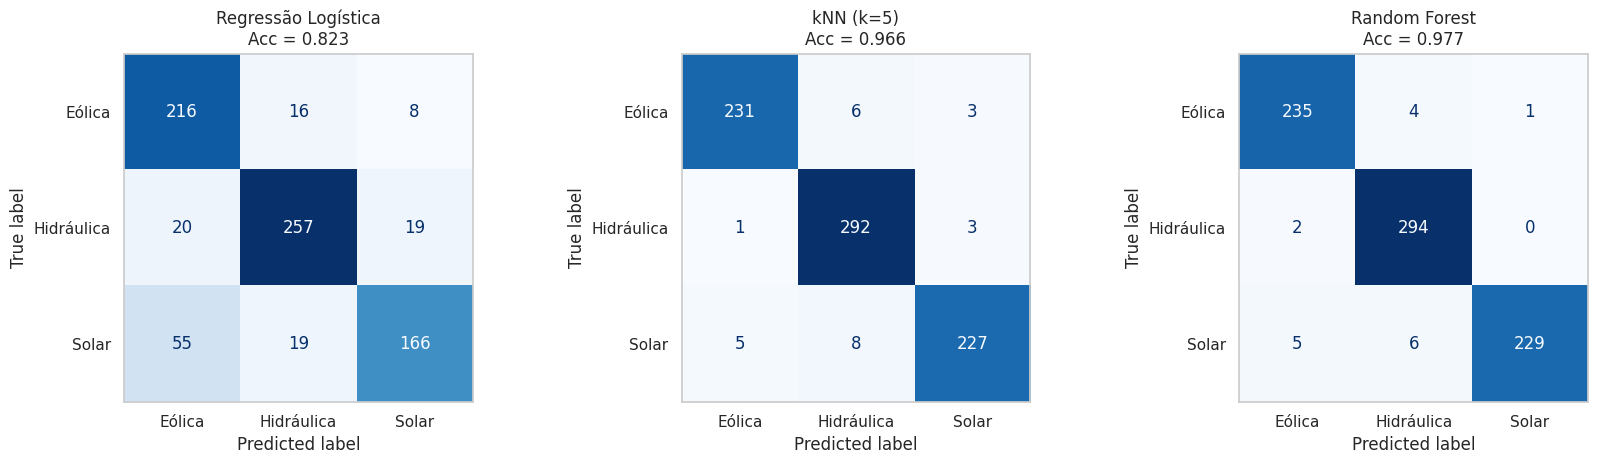

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, (nome, p) in zip(axs, previsoes_cls.items()):
    cm = confusion_matrix(y_te, p, labels=CLASSES)
    ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(f"{nome}\nAcc = {accuracy_score(y_te, p):.3f}"); ax.grid(False)
plt.tight_layout(); plt.show()

Melhor modelo (F1 macro): Random Forest


,Classe real,Prevista como,Quantidade
0,Solar,Hidráulica,6
1,Solar,Eólica,5
2,Eólica,Hidráulica,4
3,Hidráulica,Eólica,2
4,Eólica,Solar,1
5,Hidráulica,Solar,0


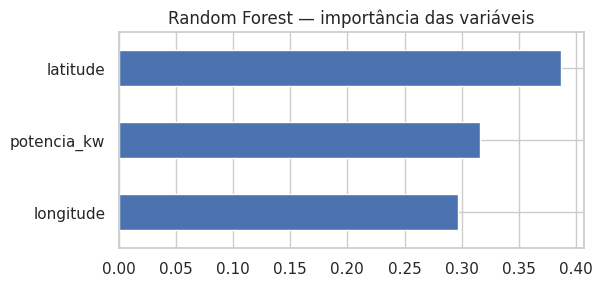

In [ ]:
# Principais confusões (erros mais frequentes) do melhor modelo por F1 macro
melhor_cls = tab_cls["F1 (macro)"].idxmax()
cm = pd.DataFrame(confusion_matrix(y_te, previsoes_cls[melhor_cls], labels=CLASSES), index=CLASSES, columns=CLASSES)
erros = [(r, c, cm.loc[r, c]) for r in CLASSES for c in CLASSES if r != c]
erros = pd.DataFrame(erros, columns=["Classe real", "Prevista como", "Quantidade"]).sort_values("Quantidade", ascending=False)
print("Melhor modelo (F1 macro):", melhor_cls)
display(erros.head(6).reset_index(drop=True))

rf = modelos_cls["Random Forest"]
imp = pd.Series(rf.feature_importances_, index=FEATURES_CLS).sort_values()
imp.plot.barh(title="Random Forest — importância das variáveis", figsize=(6, 2.8)); plt.show()

### 6. Interpretação Tarefa 1

> Valores da execução de referência (seed 42, 776 exemplos de teste); confira com as tabelas geradas na sua execução, que podem variar levemente se a API devolver dados atualizados.

- **Comparação:** Random Forest (Accuracy ≈ 0,976; F1 macro ≈ 0,975) e kNN (≈ 0,965; F1 macro ≈ 0,965) ficaram muito próximos, e ambos bem acima da Regressão Logística (≈ 0,825; F1 macro ≈ 0,820). A localização separa bem as fontes por **regiões** (vizinhança geográfica), e isso é uma estrutura não linear que a fronteira linear da Regressão Logística não representa.
- **Modelo escolhido:** **Random Forest**, por ter o melhor resultado em todas as métricas macro e por não exigir padronização. A diferença para o kNN é pequena (poucos exemplos de teste), então com outra semente/divisão a ordem entre os dois poderia mudar.
- **Classes mais confundidas (Random Forest):** o erro mais comum é **Solar prevista como Hidráulica** (7 casos) e **Solar como Eólica** (5), seguido de **Eólica como Hidráulica** (4). A Solar tem o menor recall: usinas fotovoltaicas, em geral de potência pequena e espalhadas por muitas regiões, ficam misturadas às demais. Na Regressão Logística o problema é maior, com Solar e Eólica sendo muito confundidas entre si (veja as matrizes).
- **Limitações:** (i) potência outorgada é capacidade cadastrada, não geração; (ii) só três atributos, sem altitude, hidrografia, vento ou irradiação; (iii) o cadastro mistura empreendimentos em fases diferentes; (iv) a amostra é limitada a 1.200 registros por sigla e **não** reflete a matriz brasileira; (v) coordenadas aproximadas; (vi) empreendimentos vizinhos (ex.: complexos eólicos/solares com várias unidades muito próximas) podem aparecer no treino e no teste, **favorecendo** kNN e Random Forest — a acurácia alta pode ser otimista para localizações novas; (vii) uma única divisão treino/teste, sem validação cruzada.

---
# Tarefa 2 Regressão da radiação solar (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual a radiação solar global horizontal média daquela hora (W/m²)?

- **X:** `temperatura_c`, `umidade_pct`, `nuvens_pct`, `vento_kmh`, `hora`
- **y:** `radiacao_w_m2`
- `data_hora` só serve para ordenar e dividir no tempo; **não** entra em X, e `radiacao_w_m2` não é usada para criar nenhuma entrada.
- Dados históricos estimados por modelos/reanálise, de 01/04/2025 a 30/06/2025, 7h–17h, fuso `America/Recife`.

### 7. Carga e exploração dos dados

In [ ]:
df_reg = pd.read_csv("meteo_regressao_orange.csv", encoding="utf-8-sig", parse_dates=["data_hora"])
df_reg = df_reg.sort_values("data_hora").reset_index(drop=True)   # garante a ordem temporal
print("Formato:", df_reg.shape, "| Período:", df_reg.data_hora.min(), "→", df_reg.data_hora.max())
display(df_reg.head())
print("\nValores ausentes:"); print(df_reg.isna().sum())
display(df_reg.describe().T)

Formato: (1001, 7) | Período: 2025-04-01 07:00:00 → 2025-06-30 17:00:00


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01 07:00:00,25.3000,74,100,17.7000,7,116.0000
1,2025-04-01 08:00:00,26.5000,66,100,18.1000,8,269.0000
2,2025-04-01 09:00:00,28.4000,55,97,18.0000,9,529.0000
3,2025-04-01 10:00:00,30.8000,44,21,18.4000,10,797.0000
4,2025-04-01 11:00:00,32.7000,36,26,20.1000,11,880.0000



Valores ausentes:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


,count,mean,min,25%,50%,75%,max,std
data_hora,1001,2025-05-16 11:59:59.999999744,2025-04-01 07:00:00,2025-04-23 15:00:00,2025-05-16 12:00:00,2025-06-08 09:00:00,2025-06-30 17:00:00,NaN
temperatura_c,"1,001.0000",28.8859,19.5000,26.3000,29.1000,31.7000,36.1000,3.6565
umidade_pct,"1,001.0000",50.5445,21.0000,38.0000,49.0000,61.0000,95.0000,15.9140
nuvens_pct,"1,001.0000",55.1089,0.0000,19.0000,54.0000,98.0000,100.0000,37.8515
vento_kmh,"1,001.0000",15.4654,2.3000,12.2000,15.4000,19.0000,30.1000,4.9236
hora,"1,001.0000",12.0000,7.0000,9.0000,12.0000,15.0000,17.0000,3.1639
radiacao_w_m2,"1,001.0000",472.8541,13.0000,250.0000,466.0000,696.0000,"1,002.0000",256.3690


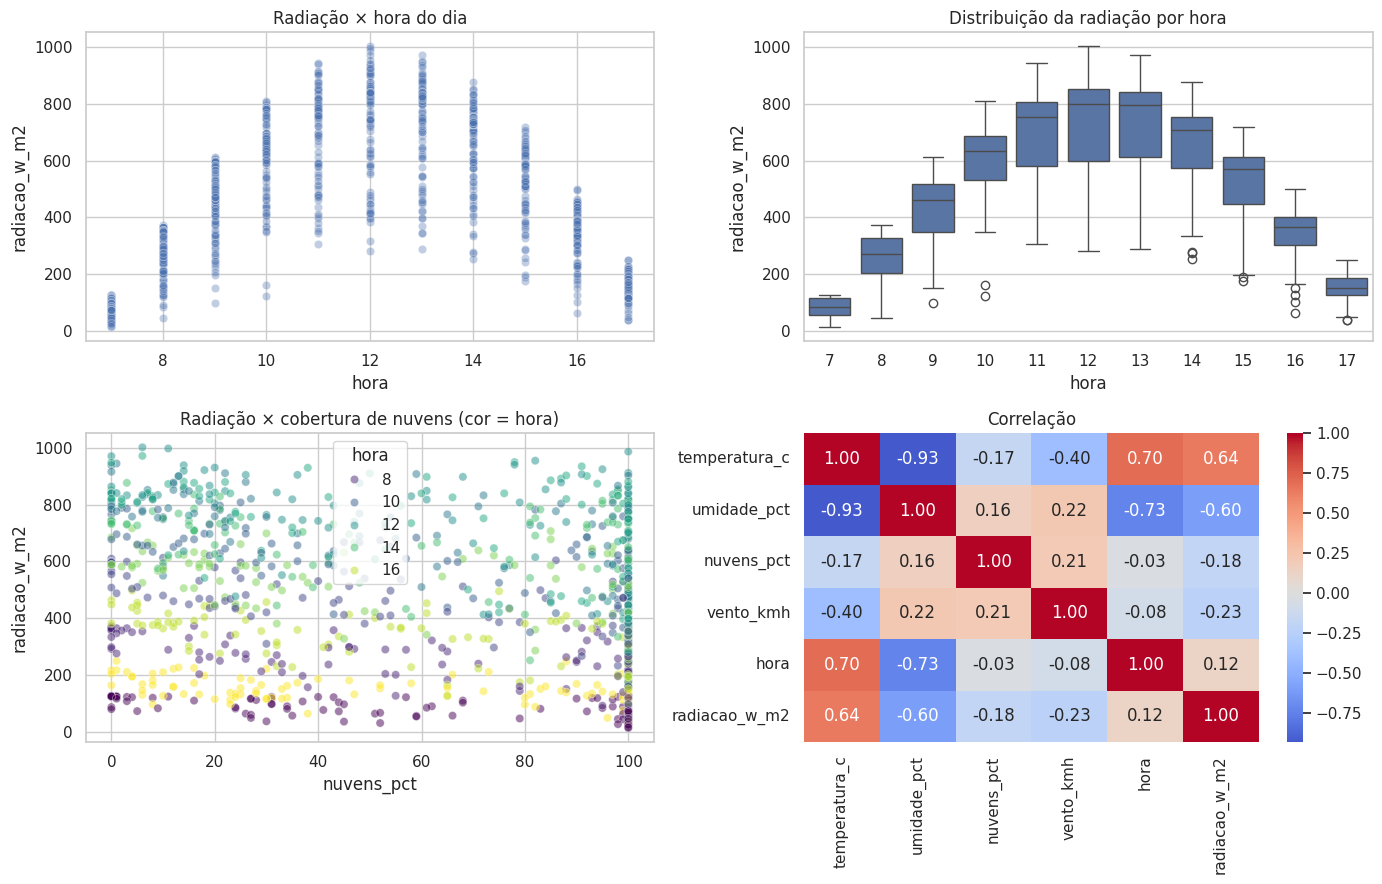

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
sns.scatterplot(data=df_reg, x="hora", y="radiacao_w_m2", alpha=.35, ax=ax[0, 0]); ax[0, 0].set_title("Radiação × hora do dia")
sns.boxplot(data=df_reg, x="hora", y="radiacao_w_m2", ax=ax[0, 1]); ax[0, 1].set_title("Distribuição da radiação por hora")
sns.scatterplot(data=df_reg, x="nuvens_pct", y="radiacao_w_m2", hue="hora", palette="viridis", alpha=.5, ax=ax[1, 0])
ax[1, 0].set_title("Radiação × cobertura de nuvens (cor = hora)")
cols = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"]
sns.heatmap(df_reg[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[1, 1]); ax[1, 1].set_title("Correlação")
plt.tight_layout(); plt.show()

**Observações da exploração.** Não há valores ausentes. Nesta amostra, as correlações lineares com a radiação são: **temperatura ≈ +0,64**, **umidade ≈ −0,60**, vento ≈ −0,23, nuvens ≈ −0,18 e hora ≈ +0,12. A correlação da `hora` é baixa porque a relação é **não linear** (a radiação sobe até perto do meio-dia e depois cai), então um coeficiente linear subestima sua importância — veja o gráfico radiação × hora. Temperatura e umidade funcionam como *indicadores indiretos* de sol (ar mais quente e seco quando há mais radiação). A cobertura de nuvens tem correlação fraca aqui, o que é um alerta: em reanálise, `cloud_cover` é uma média da coluna atmosférica e não distingue nuvens finas de espessas.

### 8. Definição de X, y e divisão temporal (primeiras 80% das horas = treino)

In [ ]:
FEATURES_REG = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]
X_r = df_reg[FEATURES_REG]
y_r = df_reg["radiacao_w_m2"]

corte = int(len(df_reg) * 0.80)       # sem embaralhar
Xr_tr, Xr_te = X_r.iloc[:corte], X_r.iloc[corte:]
yr_tr, yr_te = y_r.iloc[:corte], y_r.iloc[corte:]
print(f"Treino: {len(Xr_tr)} horas ({df_reg.data_hora.iloc[0].date()} → {df_reg.data_hora.iloc[corte-1].date()})")
print(f"Teste : {len(Xr_te)} horas ({df_reg.data_hora.iloc[corte].date()} → {df_reg.data_hora.iloc[-1].date()})")

Treino: 800 horas (2025-04-01 → 2025-06-12)
Teste : 201 horas (2025-06-12 → 2025-06-30)


### 9. Modelos
Mesma divisão temporal para os três. A Regressão Linear usa `StandardScaler` no `Pipeline` (ajustado só no treino); árvores não precisam de escala.

| Modelo | Por que foi escolhido |
|---|---|
| Regressão Linear | Linha de base; mostra o limite de uma relação linear |
| Árvore de Decisão (`max_depth=6`) | Não linear e interpretável; profundidade limitada para reduzir overfitting |
| Random Forest (300 árvores) | Média de várias árvores: mais estável e geralmente mais precisa |

In [ ]:
modelos_reg = {
    "Regressão Linear": make_pipeline(StandardScaler(), LinearRegression()),
    "Árvore de Decisão": DecisionTreeRegressor(max_depth=6, random_state=SEED),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1),
}
linhas, previsoes_reg = [], {}
for nome, m in modelos_reg.items():
    m.fit(Xr_tr, yr_tr)
    p = m.predict(Xr_te); previsoes_reg[nome] = p
    linhas.append({"Modelo": nome,
                   "MAE (W/m²)": mean_absolute_error(yr_te, p),
                   "MSE ((W/m²)²)": mean_squared_error(yr_te, p),
                   "RMSE (W/m²)": np.sqrt(mean_squared_error(yr_te, p)),
                   "R²": r2_score(yr_te, p)})
tab_reg = pd.DataFrame(linhas).set_index("Modelo")
print("Métricas no conjunto de teste (últimos 20% das horas, mesma divisão temporal para os três modelos).")
display(tab_reg.style.highlight_min(subset=["MAE (W/m²)", "MSE ((W/m²)²)", "RMSE (W/m²)"], color="#c8e6c9")
                     .highlight_max(subset=["R²"], color="#c8e6c9").format("{:.3f}"))

Métricas no conjunto de teste (últimos 20% das horas, mesma divisão temporal para os três modelos).


,MAE (W/m²),MSE ((W/m²)²),RMSE (W/m²),R²
Modelo,,,,
Regressão Linear,145.205,30034.201,173.304,0.360
Árvore de Decisão,90.938,15127.027,122.992,0.678
Random Forest,66.399,7210.084,84.912,0.846


### 10. Gráficos: valores reais × previstos

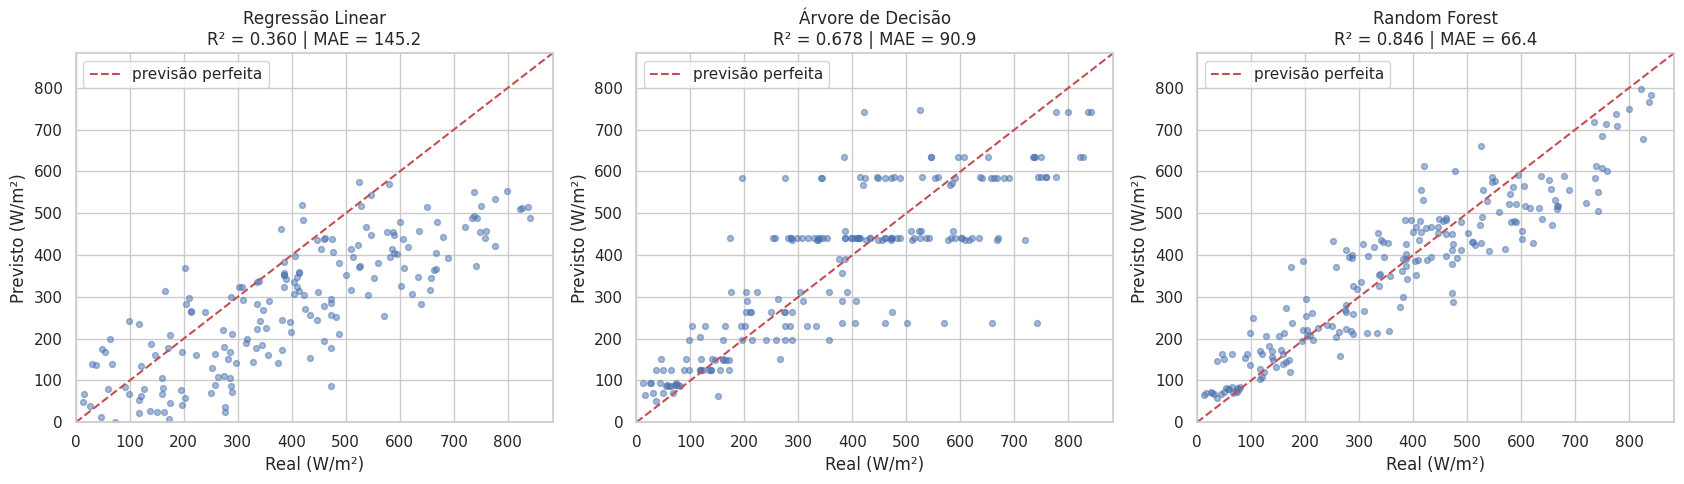

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(17, 5))
lim = [0, max(yr_te.max(), max(p.max() for p in previsoes_reg.values())) * 1.05]
for ax, (nome, p) in zip(axs, previsoes_reg.items()):
    ax.scatter(yr_te, p, alpha=.5, s=18)
    ax.plot(lim, lim, "r--", label="previsão perfeita")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Real (W/m²)"); ax.set_ylabel("Previsto (W/m²)")
    ax.set_title(f"{nome}\nR² = {r2_score(yr_te, p):.3f} | MAE = {mean_absolute_error(yr_te, p):.1f}"); ax.legend()
plt.tight_layout(); plt.show()

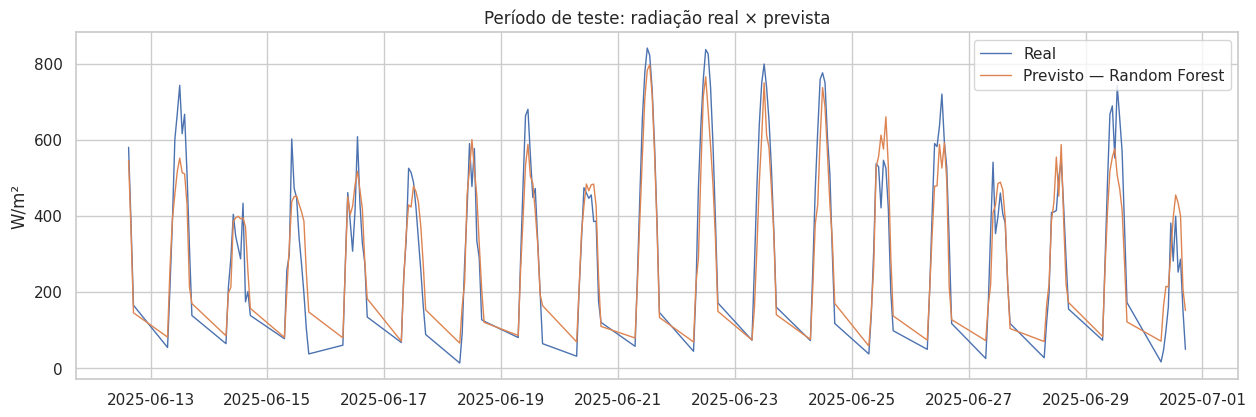

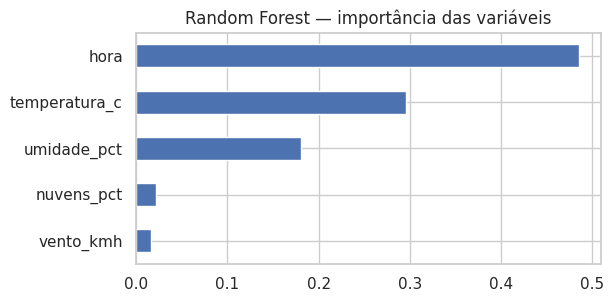

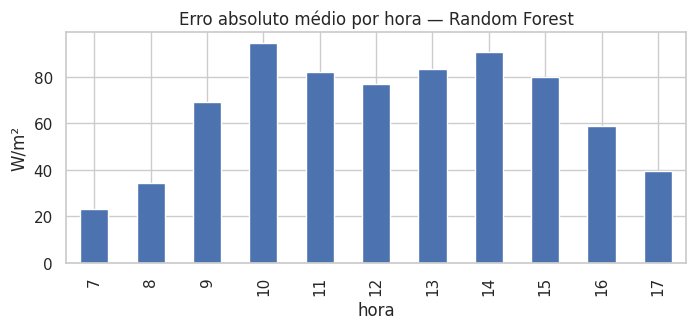

In [ ]:
melhor_reg = tab_reg["MAE (W/m²)"].idxmin()
datas_te = df_reg.data_hora.iloc[corte:]
plt.figure(figsize=(15, 4.5))
plt.plot(datas_te.values, yr_te.values, label="Real", lw=1)
plt.plot(datas_te.values, previsoes_reg[melhor_reg], label=f"Previsto — {melhor_reg}", lw=1)
plt.title("Período de teste: radiação real × prevista"); plt.ylabel("W/m²"); plt.legend(); plt.show()

rf_r = modelos_reg["Random Forest"]
pd.Series(rf_r.feature_importances_, index=FEATURES_REG).sort_values().plot.barh(
    title="Random Forest — importância das variáveis", figsize=(6, 3)); plt.show()

# Resíduos por hora do melhor modelo
res = pd.DataFrame({"hora": Xr_te["hora"].values, "erro_abs": np.abs(yr_te.values - previsoes_reg[melhor_reg])})
res.groupby("hora")["erro_abs"].mean().plot.bar(title=f"Erro absoluto médio por hora — {melhor_reg}", figsize=(8, 3)); plt.ylabel("W/m²"); plt.show()

### 11. Interpretação  Tarefa 2

> Valores da execução de referência (treino até 12/06/2025 14h; teste de 12/06 15h a 30/06/2025).

| Modelo | MAE (W/m²) | MSE ((W/m²)²) | R² |
|---|---|---|---|
| Regressão Linear | ≈ 145 | ≈ 30.034 | ≈ 0,36 |
| Árvore de Decisão (prof. 6) | ≈ 91 | ≈ 15.127 | ≈ 0,68 |
| Random Forest | ≈ 66 | ≈ 7.210 | ≈ 0,85 |

- **Comparação:** o **Random Forest** é o melhor (menor MAE/MSE, maior R²). A **Regressão Linear** é a pior (R² ≈ 0,36), pois a radiação não é linear na hora (curva em sino) e depende de interações (hora × temperatura × umidade). A Árvore de Decisão captura parte dessa estrutura, e a floresta, ao fazer a média de várias árvores, reduz a variância.
- **Papel da hora:** no Random Forest, a `hora` é a variável mais importante (≈ 0,49 de importância), seguida de `temperatura_c` (≈ 0,30) e `umidade_pct` (≈ 0,18); `nuvens_pct` (≈ 0,02) e `vento_kmh` (≈ 0,02) pesam pouco. A hora define o ângulo do Sol e, portanto, o "teto" físico de radiação; as demais descrevem o quanto desse teto chega ao solo. Como a relação é não linear, a hora quase não aparece na correlação de Pearson, mas é decisiva nos modelos de árvore.
- **Erros:** o erro absoluto é maior nas horas centrais do dia, quando os valores de radiação são altos e a variação por nebulosidade pode ser de centenas de W/m². Ver o gráfico de erro por hora.
- **Divisão temporal:** treino e teste são períodos consecutivos. Como a radiação cai com a chegada do inverno, o teste tem condições ligeiramente diferentes do treino; isso é intencional (simula "prever o futuro"), mas só cobre ~3 meses de uma única estação, então os resultados não valem para o ano todo.
- **Radiação ≠ geração elétrica:** a radiação (W/m²) é uma estimativa de reanálise para a superfície **horizontal** em um ponto. A geração fotovoltaica depende ainda de inclinação e orientação dos painéis, área e eficiência, temperatura da célula, sombreamento, sujeira, perdas no inversor/rede, degradação e disponibilidade. Estimar radiação é uma etapa para estimar energia (kWh), não a previsão da geração.

---
# Conclusão geral

| Tarefa | Melhor modelo | Observação |
|---|---|---|
| 1 — Classificação | Random Forest (Acc ≈ 0,976), seguido de perto pelo kNN | Localização separa bem as fontes; potência e localização não bastam para uma aplicação real |
| 2 — Regressão | Random Forest (MAE ≈ 66 W/m², R² ≈ 0,85) | Hora, temperatura e umidade dominam; estimar radiação não é prever geração |

**Fontes:** [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) · [Open-Meteo — API histórica](https://open-meteo.com/en/docs/historical-weather-api)